### Notebook 7: LangGraph Conversational Agent with Memory

The LangGraph equivalent of notebook 6. A conversational orchestrator
that persists state across turns using LangGraph's checkpointer, calls
the same ADK A2A agents over HTTP, and can ask the user for
clarification when information is missing.

### 1. Imports and Configuration

In [ ]:
import sys
import os
import time
import subprocess
import logging
import uuid
import json
from pathlib import Path
from typing import TypedDict, Annotated

import httpx
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / "environment" / ".env")

from config import strip_emojis

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt = "%H:%M:%S",
)
logging.getLogger("google.genai").setLevel(logging.ERROR)
log = logging.getLogger(__name__)

### 2. Start A2A Servers

In [ ]:
AGENTS = {
    "mortgage":   {"module": "agents.mortgage_agent:a2a_app",   "port": 8001},
    "risk":       {"module": "agents.risk_agent:a2a_app",       "port": 8002},
    "investment": {"module": "agents.investment_agent:a2a_app",  "port": 8003},
}

processes = {}

for name, cfg in AGENTS.items():
    cmd = [
        sys.executable, "-m", "uvicorn",
        cfg["module"],
        "--host", "localhost",
        "--port", str(cfg["port"]),
        "--log-level", "warning",
    ]
    proc = subprocess.Popen(
        cmd, cwd=str(PROJECT_ROOT),
        stdout=subprocess.PIPE, stderr=subprocess.PIPE,
    )
    processes[name] = proc
    log.info("started %s on port %d (pid=%d)", name, cfg["port"], proc.pid)

time.sleep(5)
log.info("A2A servers ready.")

06:57:49  INFO      A2A servers ready.


### 3. A2A Client

In [4]:
def call_a2a_agent(url: str, message: str, verbose: bool = True) -> str:
    """Send a message to an A2A agent and return the text response.

    A2A uses JSON-RPC 2.0 over HTTP. Each request is a standard POST
    with a JSON body containing a method name and params. The server
    processes the request and returns a JSON-RPC response with a
    result field containing the agent's output.
    """

    # ---------------------------------------------------------------
    # Build the JSON-RPC 2.0 request payload.
    # - jsonrpc: protocol version (always "2.0")
    # - id: unique request identifier, used to match responses
    # - method: the A2A RPC method ("message/send" for synchronous)
    # - params.message: the actual user message in A2A format
    #   - role: "user" for incoming queries
    #   - parts: list of content parts (text, images, etc.)
    #   - messageId: unique ID for this specific message
    # ---------------------------------------------------------------

    request_id = str(uuid.uuid4())
    message_id = str(uuid.uuid4())

    payload = {
        "jsonrpc": "2.0",
        "id": request_id,
        "method": "message/send",
        "params": {
            "message": {
                "role": "user",
                "parts": [{"kind": "text", "text": message}],
                "messageId": message_id,
            }
        },
    }

    if verbose:
        log.info("--- A2A REQUEST to %s ---", url)
        log.info("method: %s", payload["method"])
        log.info("message: %s", message[:150])
        log.info("payload:\n%s", json.dumps(payload, indent=2))

    # ---------------------------------------------------------------
    # Send the HTTP POST request. The A2A server is a standard HTTP
    # endpoint any language or framework can call.
    # ---------------------------------------------------------------

    r = httpx.post(url, json=payload, timeout=60)
    r.raise_for_status()
    response_json = r.json()

    if verbose:
        log.info("--- A2A RESPONSE from %s ---", url)
        log.info("status: %d", r.status_code)
        # Truncate for readability
        response_str = json.dumps(response_json, indent=2)
        if len(response_str) > 500:
            log.info("response (truncated):\n%s\n... [%d chars total]",
                     response_str[:500], len(response_str))
        else:
            log.info("response:\n%s", response_str)

    # ---------------------------------------------------------------
    # Parse the JSON-RPC response.
    #
    # A2A responses contain a Task object with:
    # - artifacts: list of output content (the agent's final answer)
    #   - each artifact has parts with kind="text"
    # - status: task state (completed, failed, input_required)
    #   - status.message: may contain text if no artifacts
    #
    # We check artifacts first (preferred), then fall back to
    # status.message for simpler responses.
    # ---------------------------------------------------------------

    result = response_json.get("result", {})

    if isinstance(result, dict):
        # Preferred: extract from artifacts
        artifacts = result.get("artifacts", [])
        for artifact in artifacts:
            for part in artifact.get("parts", []):
                if part.get("kind") == "text":
                    return part["text"]

        # Fallback: extract from status message
        status = result.get("status", {})
        msg = status.get("message", {})
        if isinstance(msg, dict):
            for part in msg.get("parts", []):
                if part.get("kind") == "text":
                    return part["text"]
        elif isinstance(msg, str):
            return msg

    return str(result)

### 4. LangGraph Conversational Orchestrator

The key difference from notebook 5's LangGraph orchestrator:

- **Message history in state:** The state carries a list of messages (user + assistant) that grows with each turn. The LLM sees the fullconversation every time.
- **MemorySaver checkpointer:** LangGraph persists the state between `invoke()` calls using a thread_id. Same concept as ADK's session_id.
- **Single decision node:** Instead of fan-out to all agents, the LLM decides per-turn whether to call an agent, ask for clarification, or respond directly

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage

# -----------------------------------------------------------------------
# State schema -- messages accumulate across turns
# -----------------------------------------------------------------------

class ConversationState(TypedDict):
    messages: list          # full conversation history
    pending_action: str     # what the LLM wants to do (call agent or respond)
    agent_result: str       # result from an A2A agent call

# -----------------------------------------------------------------------
# LLM
# -----------------------------------------------------------------------

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    google_api_key=os.environ.get("GOOGLE_API_KEY"),
)

# -----------------------------------------------------------------------
# System prompt for the orchestrator
# -----------------------------------------------------------------------

SYSTEM_PROMPT = (
    "You are a financial services coordinator. You help users with "
    "mortgage calculations, risk assessments, and investment projections "
    "by delegating to specialist agents.\n\n"
    "Available specialists:\n"
    "- MORTGAGE: payment calculations, amortization, affordability\n"
    "- RISK: credit risk scoring, loan risk assessment\n"
    "- INVESTMENT: compound interest, ROI, savings goals\n\n"
    "Rules:\n"
    "- If the user's query is missing critical information, ask for it. "
    "Do not guess values.\n"
    "- When you have enough information to delegate, respond with EXACTLY "
    "one of these on the first line: CALL:MORTGAGE, CALL:RISK, or "
    "CALL:INVESTMENT, followed by a newline and then the full query to "
    "send to the specialist (include all relevant details from the "
    "conversation so far).\n"
    "- If you are asking for clarification or responding directly, just "
    "write your response normally (no CALL: prefix).\n"
    "- After receiving a specialist's result, present it to the user "
    "and ask if they need anything else."
)

A2A_URLS = {
    "MORTGAGE":   "http://localhost:8001",
    "RISK":       "http://localhost:8002",
    "INVESTMENT": "http://localhost:8003",
}

# -----------------------------------------------------------------------
# Node functions
# -----------------------------------------------------------------------

def decide_node(state: ConversationState) -> dict:
    """LLM decides whether to call an agent or respond to the user."""
    # Build message list with system prompt
    llm_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    llm_messages.extend(state["messages"])

    response = llm.invoke(llm_messages)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]

    # Check if the LLM wants to call a specialist
    first_line = content.strip().split("\n")[0]
    if first_line.startswith("CALL:"):
        agent_key = first_line.replace("CALL:", "").strip()
        # The rest is the query for the specialist
        query = "\n".join(content.strip().split("\n")[1:]).strip()
        log.info("[orchestrator] delegating to %s", agent_key)
        log.info("[orchestrator] query: %s", query[:150])
        return {
            "pending_action": f"CALL:{agent_key}",
            "agent_result": "",
            "messages": state["messages"],  # preserve history
        }
    else:
        # Direct response to user (clarification or final answer)
        log.info("[orchestrator] responding directly")
        new_messages = state["messages"] + [
            {"role": "assistant", "content": content}
        ]
        return {
            "pending_action": "RESPOND",
            "agent_result": content,
            "messages": new_messages,
        }


def call_agent_node(state: ConversationState) -> dict:
    """Call the appropriate A2A agent based on pending_action."""
    action = state.get("pending_action", "")
    if not action.startswith("CALL:"):
        return state

    agent_key = action.replace("CALL:", "").strip()
    url = A2A_URLS.get(agent_key)
    if not url:
        error_msg = f"Unknown specialist: {agent_key}"
        log.error(error_msg)
        return {
            "pending_action": "RESPOND",
            "agent_result": error_msg,
            "messages": state["messages"] + [
                {"role": "assistant", "content": error_msg}
            ],
        }

    # Extract the query from the last decide_node output
    # Re-invoke LLM to get the full query (since we only stored the action)
    llm_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    llm_messages.extend(state["messages"])
    response = llm.invoke(llm_messages)
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]
    query = "\n".join(content.strip().split("\n")[1:]).strip()
    if not query:
        query = state["messages"][-1].get("content", "") if state["messages"] else ""

    log.info("[%s] calling A2A agent at %s", agent_key, url)
    result = call_a2a_agent(url, query)
    log.info("[%s] result received (%d chars)", agent_key, len(result))

    # Add the result to conversation as an assistant message
    summary = f"Specialist ({agent_key}) report:\n\n{result}"
    new_messages = state["messages"] + [
        {"role": "assistant", "content": summary}
    ]

    return {
        "pending_action": "RESPOND",
        "agent_result": result,
        "messages": new_messages,
    }


def route(state: ConversationState) -> str:
    """Route to call_agent if a CALL: action is pending, otherwise end."""
    action = state.get("pending_action", "")
    if action.startswith("CALL:"):
        return "call_agent"
    return END


# -----------------------------------------------------------------------
# Build the graph
# -----------------------------------------------------------------------

graph = StateGraph(ConversationState)
graph.add_node("decide", decide_node)
graph.add_node("call_agent", call_agent_node)

graph.set_entry_point("decide")
graph.add_conditional_edges("decide", route, {"call_agent": "call_agent", END: END})
graph.add_edge("call_agent", END)

# MemorySaver persists state across invoke() calls using thread_id.
# This is the LangGraph equivalent of ADK's session persistence.
memory = MemorySaver()
orchestrator = graph.compile(checkpointer=memory)

### 5. Graph Visualisation

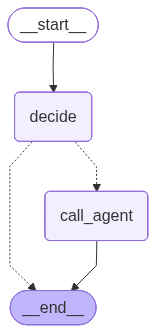

In [6]:
from IPython.display import Image

try:
    display(Image(orchestrator.get_graph().draw_mermaid_png()))
except Exception:
    print(orchestrator.get_graph().draw_mermaid())

### 6. Conversational Loop

Same pattern as notebook 6: a `while True` loop that reads user input
and feeds it into the graph. The difference is how state persistence
works:

- **ADK (notebook 6):** Session ID passed to `run_async()`, ADK manages
  the event history internally.
- **LangGraph (this notebook):** Thread ID passed in config, MemorySaver
  checkpointer persists the full state dict between invocations.

Both achieve the same result: the orchestrator remembers the full
conversation.

In [7]:
# -----------------------------------------------------------------------
# Conversational loop with LangGraph.
#
# The thread_id in the config is the equivalent of ADK's session_id.
# As long as every invoke() uses the same thread_id, the MemorySaver
# checkpointer restores the full conversation state, including the
# messages list that accumulates across turns.
# -----------------------------------------------------------------------

THREAD_ID = str(uuid.uuid4())
config = {"configurable": {"thread_id": THREAD_ID}}

log.info("thread_id: %s", THREAD_ID)
log.info("type a financial question, or 'quit' to exit")

while True:
    user_input = input("You: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        log.info("conversation ended")
        break

    # Get current state to access messages history
    current_state = orchestrator.get_state(config)
    existing_messages = []
    if current_state and current_state.values:
        existing_messages = current_state.values.get("messages", [])

    # Add the new user message
    messages = existing_messages + [{"role": "user", "content": user_input}]

    result = orchestrator.invoke(
        {"messages": messages, "pending_action": "", "agent_result": ""},
        config=config,
    )

    # Display the last assistant message
    last_response = result.get("agent_result", "")
    if last_response:
        display(Markdown(f"**Orchestrator:**\n\n{strip_emojis(last_response)}"))

07:02:03  INFO      thread_id: f5f93b0b-e737-4443-9319-25e713f3c906
07:02:03  INFO      type a financial question, or 'quit' to exit
07:02:12  INFO      AFC is enabled with max remote calls: 10.
07:02:14  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:02:14  INFO      [orchestrator] responding directly


**Orchestrator:**

I'd be happy to help you with that. To provide you with accurate calculations or affordability information, could you please provide a few details such as:

- The total loan amount (or the price of the home and your down payment)
- The interest rate
- The loan term (e.g., 15, 20, or 30 years)

If you're looking to see how much you can afford, knowing your annual income and monthly debts would also be helpful.

07:02:49  INFO      AFC is enabled with max remote calls: 10.
07:02:51  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:02:51  INFO      [orchestrator] responding directly


**Orchestrator:**

That sounds like a solid plan. To calculate your monthly payments and provide an amortization schedule, I just need one more piece of information:

- What is the **interest rate** you are expecting or would like me to use for the calculation?

07:03:10  INFO      AFC is enabled with max remote calls: 10.
07:03:13  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:03:13  INFO      [orchestrator] responding directly


...

07:03:33  INFO      AFC is enabled with max remote calls: 10.
07:03:40  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:03:40  INFO      [orchestrator] delegating to RISK
07:03:40  INFO      [orchestrator] query: Evaluate the credit risk and suggest a suitable interest rate for a borrower with a 700 credit score and a $30,000 gross annual income. The borrower i
07:03:40  INFO      AFC is enabled with max remote calls: 10.
07:03:45  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:03:45  INFO      [RISK] calling A2A agent at http://localhost:8002
07:03:45  INFO      --- A2A REQUEST to http://localhost:8002 ---
07:03:45  INFO      method: message/send
07:03:45  INFO      message: Assess the loan risk and provide a recommended interest rate for a borrower with a credit score of 700 and an annual inc

**Orchestrator:**

To assess the loan risk and calculate a composite score, I need a bit more information. Specifically, could you provide:

1. **Years at current employer:** This helps determine employment stability.
2. **An interest rate to test:** Since I don't have a tool to recommend a market interest rate, I can use a standard rate (e.g., 7%) to calculate your monthly payment and assess the risk, or you can provide a specific rate you'd like me to evaluate.

Once I have the employment years, I can calculate your credit risk score and perform a full loan risk assessment. For now, I have calculated your **Loan-to-Value (LTV) ratio at 90%** ($180,000 / $200,000), which is a key factor in the assessment.

07:05:13  INFO      AFC is enabled with max remote calls: 10.
07:05:18  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:05:18  INFO      [orchestrator] delegating to RISK
07:05:18  INFO      [orchestrator] query: Please perform a risk assessment for the following loan application:
- Home Price: $200,000
- Down Payment: $20,000 (Loan Amount: $180,000)
- Interest
07:05:18  INFO      AFC is enabled with max remote calls: 10.
07:05:22  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
07:05:22  INFO      [RISK] calling A2A agent at http://localhost:8002
07:05:22  INFO      --- A2A REQUEST to http://localhost:8002 ---
07:05:22  INFO      method: message/send
07:05:22  INFO      message: Please perform a risk assessment and credit scoring for the following loan application:
- Home Price: $200,000
- Down Pa

**Orchestrator:**

Based on my analysis, here is the risk assessment and credit scoring for the loan application:

### **Credit Risk Profile**
*   **Composite Credit Score:** 60/100
*   **Risk Category:** **MODERATE RISK**
*   **Key Strengths:** 
    *   **Employment Stability:** Excellent (15 years at current employer).
    *   **Credit History:** Good (Credit score of 700).
    *   **Clean Record:** No bankruptcies or recent missed payments.
*   **Key Concern:** The Debt-to-Income (DTI) ratio of **55.8%** is significantly higher than standard industry limits.

### **Loan Assessment & Recommendation**
*   **Recommendation:** **DENY**
*   **Overall Risk Level:** **HIGH**
*   **Reasoning:**
    *   **DTI Ratio:** At 55.8%, the total debt burden is far beyond the conventional threshold (typically 43%).
    *   **Housing Affordability:** The monthly mortgage payment ($1,395.52) would consume over 55% of the applicant's gross monthly income ($2,500), which presents a high risk of default.
    *   **LTV Ratio:** The Loan-to-Value ratio is 90% (with a 10% down payment), which is acceptable but would likely require Private Mortgage Insurance (PMI).

**Summary:** While the applicant has a solid credit history and exceptional job stability, the loan amount is too high relative to their current income. To qualify, the applicant would likely need a significantly higher income, a much larger down payment to reduce the loan amount, or a less expensive property.

07:05:46  INFO      conversation ended


### 7. Shutdown

In [8]:
for name, proc in processes.items():
    proc.terminate()
    proc.wait(timeout=5)
    log.info("stopped %s (pid=%d)", name, proc.pid)

processes.clear()
log.info("All A2A servers stopped.")

07:05:58  INFO      stopped mortgage (pid=40305)
07:05:59  INFO      stopped risk (pid=40306)
07:05:59  INFO      stopped investment (pid=40307)
07:05:59  INFO      All A2A servers stopped.
